<!-- # Building Your Own Image Dataset

In this exercise, you'll collect your own dataset of **kitchen items**.  
Later in the course, we'll use this dataset to train an image classifier using deep learning!

---
## Task 1: Collect Your Own Images
- Take **20–30 photos** of 3–4 different kitchen items (e.g., mug, spoon, kettle)
- Include: Spoon, Knife, Pan, Cup, Scissors
- You can also include more items
- Take multiple pictures of all items from different angles
- Put the item in the center of the image
- Use **good lighting** and a **plain background** 
- Take photos from **different angles** and distances
- Save the images as `.jpg`
- Crop and resize images to 800px x 600px


### File Naming Convention
Please name your files like this:
```
objectname_studentID_number.jpg
```
`studentID = first letter of name + first letter of lastname + birthday (day)`
```
spoon_JL29_01.jpg
```

---
### Folder Structure
You should place your images in a single folder.

Put the exported file from label-studio next to the folder. -->

In [7]:
import os
import tensorflow as tf

In [8]:
print("Start")
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# Enter either 0 or 1 below to select the GPU to use
os.environ["CUDA_VISIBLE_DEVICES"]="1"
physical_devices = tf.config.experimental.list_physical_devices('GPU')
tf.config.set_visible_devices(physical_devices[0], 'GPU')
tf.config.experimental.set_memory_growth(physical_devices[0], True)

Start
Num GPUs Available: 0


IndexError: list index out of range

In [ ]:
import pandas as pd
import json
from pathlib import Path
from matplotlib import pyplot as plt
import cv2
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from keras.models import Sequential

from keras.layers import Dense, Dropout, Activation, Conv2D, BatchNormalization, MaxPooling2D, Flatten

# Read all dataframes

In [ ]:
# iterate over all dataframes in the dataframes folder and concatenate them
dataframes_path = Path("./dataframes")
dataframes = []
for file in dataframes_path.glob("*.pkl"):
    df = pd.read_pickle(file)
    dataframes.append(df)
df = pd.concat(dataframes, ignore_index=True)
df.head()

,Image_name,Image_data,X_pos,Y_pos,Width,Height,Student_id,OriginalWidth,OriginalHeight
0,Glass,"[[[218, 187, 143], [224, 193, 149], [229, 198,...",162.171946,362.956259,528.989442,828.235294,IO05,960,1280
1,Kettle,"[[[163, 156, 138], [163, 156, 138], [163, 156,...",40.542986,214.298643,868.778281,903.529412,IO05,960,1280
2,Whisk,"[[[192, 186, 186], [193, 187, 187], [194, 188,...",111.975867,469.140271,756.802413,405.429864,IO05,960,1280
3,Plate,"[[[179, 175, 174], [179, 175, 174], [178, 174,...",192.147806,73.903002,932.655889,854.318707,IO05,1280,960
4,Pan,"[[[219, 204, 197], [219, 204, 197], [220, 205,...",36.681750,534.781297,897.737557,486.515837,IO05,960,1280


In [ ]:
df = df[~df.Student_id.isna()]

In [ ]:
df = df[["Image_name", "Image_data", "X_pos", "Y_pos", "Width", "Height", "Student_id", "OriginalWidth", "OriginalHeight"]]
df = df[(df.OriginalWidth == 1024) & (df.OriginalHeight == 1024)]

# Data Augmentation examples

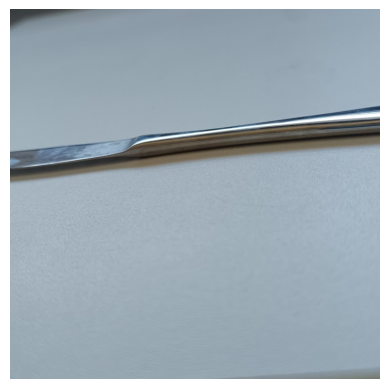

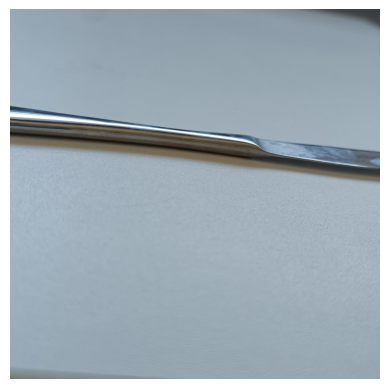

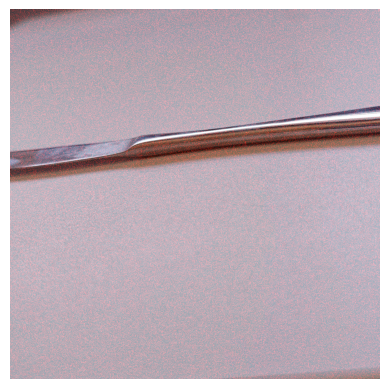

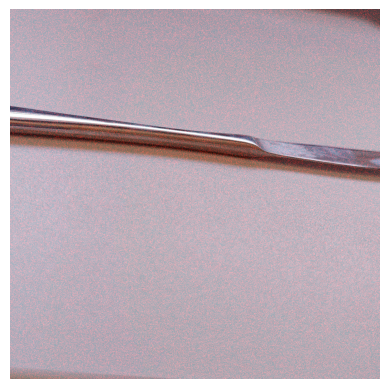

In [ ]:
def show_image(image):
    plt.imshow(image)
    plt.axis('off')
    plt.show()

def flip_image(image):
    flipped_image = cv2.flip(image, 2)
    return flipped_image

def add_noise(image):
    noise = cv2.randn(image.copy(), 0, 100)  # Add Gaussian noise
    noisy_image = cv2.add(image, noise)
    return noisy_image


In [ ]:
df.Image_name.unique()

array(['Cup', 'Fork', 'Kettle', 'Knife', 'Pan', 'Scissors', 'Spoon',
       'beeropener', 'breadknife', 'chopsticks', 'corkscrew',
       'espressocup', 'grater', 'milkpitcher', 'mokapot', 'peeler',
       'peppermill', 'saucer', 'shotglass', 'spatula', 'spoon', 'tamper',
       'whisk', 'Clip', 'Peeler', 'Boiler', 'Towel', 'wooden Spoon',
       'Glass', 'Plate'], dtype=object)

In [ ]:
df.OriginalWidth.unique()

array([1024])

In [ ]:
df.OriginalHeight.unique()

array([1024])

In [ ]:
len(df)

162

In [ ]:
df.Student_id.unique()

array(['YS09', 'LS12', 'VS30', 'XS15', 'BB09', 'KK27'], dtype=object)

In [ ]:
df["Augmentation"] = False

In [ ]:
noise_df = df.copy()
noise_df["Image_data"] = noise_df["Image_data"].apply(add_noise)
noise_df["Augmentation"] = True
noise_df.head()

,Image_name,Image_data,X_pos,Y_pos,Width,Height,Student_id,OriginalWidth,OriginalHeight,Augmentation
5,Cup,"[[[249, 202, 208], [195, 202, 208], [218, 202,...",104.727273,7.272727,785.454545,752.000000,YS09,1024,1024,True
6,Cup,"[[[34, 34, 36], [34, 34, 36], [86, 34, 36], [5...",69.818182,53.818182,836.363636,744.727273,YS09,1024,1024,True
7,Cup,"[[[224, 109, 107], [190, 112, 110], [115, 116,...",10.181818,139.636364,583.272727,680.727273,YS09,1024,1024,True
8,Fork,"[[[135, 148, 157], [255, 148, 157], [255, 148,...",331.636364,120.727273,285.090909,704.000000,YS09,1024,1024,True
9,Fork,"[[[155, 165, 167], [255, 165, 167], [255, 165,...",308.363636,1.454545,283.636364,1015.272727,YS09,1024,1024,True


In [ ]:
# Combine original and augmented dataframes
df = pd.concat([df, noise_df], ignore_index=True)

In [ ]:
flip_df = df.copy()
flip_df["Image_data"] = flip_df["Image_data"].apply(flip_image)
flip_df["Augmentation"] = True

df = pd.concat([df, flip_df], ignore_index=True)
df.head()

,Image_name,Image_data,X_pos,Y_pos,Width,Height,Student_id,OriginalWidth,OriginalHeight,Augmentation
0,Cup,"[[[195, 202, 208], [195, 202, 208], [195, 202,...",104.727273,7.272727,785.454545,752.000000,YS09,1024,1024,False
1,Cup,"[[[34, 34, 36], [34, 34, 36], [34, 34, 36], [3...",69.818182,53.818182,836.363636,744.727273,YS09,1024,1024,False
2,Cup,"[[[103, 109, 107], [106, 112, 110], [110, 116,...",10.181818,139.636364,583.272727,680.727273,YS09,1024,1024,False
3,Fork,"[[[135, 148, 157], [135, 148, 157], [135, 148,...",331.636364,120.727273,285.090909,704.000000,YS09,1024,1024,False
4,Fork,"[[[155, 165, 167], [155, 165, 167], [155, 165,...",308.363636,1.454545,283.636364,1015.272727,YS09,1024,1024,False


# Model Training

In [ ]:
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Filter only non-augmented samples for now
df_clean = df[df.Augmentation == False]
df_clean.Image_name = df_clean.Image_name.apply(lambda x: x.lower())

/tmp/ipykernel_3578236/710804504.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.Image_name = df_clean.Image_name.apply(lambda x: x.lower())


In [ ]:
# Checkout the different classes to see whether there are the same ones with different names
df_clean.Image_name.unique()

array(['cup', 'fork', 'kettle', 'knife', 'pan', 'scissors', 'spoon',
       'beeropener', 'breadknife', 'chopsticks', 'corkscrew',
       'espressocup', 'grater', 'milkpitcher', 'mokapot', 'peeler',
       'peppermill', 'saucer', 'shotglass', 'spatula', 'tamper', 'whisk',
       'clip', 'boiler', 'towel', 'wooden spoon', 'glass', 'plate'],
      dtype=object)

In [ ]:
# see how many samples we have per class
df_clean.Image_name.value_counts()

Image_name
knife           30
cup             22
spoon           17
pan             13
boiler           9
scissors         8
wooden spoon     7
fork             6
towel            6
peeler           6
plate            6
kettle           5
glass            4
clip             4
espressocup      3
chopsticks       2
shotglass        2
peppermill       2
beeropener       1
breadknife       1
corkscrew        1
spatula          1
milkpitcher      1
mokapot          1
grater           1
saucer           1
tamper           1
whisk            1
Name: count, dtype: int64

In [ ]:
# combine similar classes (e.g. shot glass and glass)
name_mapper_dict = dict(zip(
    ['cup', 'fork', 'kettle', 'knife', 'pan', 'scissors', 'spoon',
       'beeropener', 'breadknife', 'chopsticks', 'corkscrew',
       'espressocup', 'grater', 'milkpitcher', 'mokapot', 'peeler',
       'peppermill', 'saucer', 'shotglass', 'spatula', 'tamper', 'whisk',
       'clip', 'boiler', 'towel', 'wooden spoon', 'glass', 'plate'], 
    ['cup', 'fork', 'kettle', 'knife', 'pan', 'scissors', 'spoon',
       'beeropener', 'breadknife', 'chopsticks', 'corkscrew',
       'espressocup', 'grater', 'milkpitcher', 'mokapot', 'peeler',
       'peppermill', 'saucer', 'glass', 'spatula', 'tamper', 'whisk',
       'clip', 'boiler', 'towel', 'spoon', 'glass', 'plate']
    ))
df_clean.Image_name = df_clean.Image_name.map(name_mapper_dict)

In [ ]:
df_clean.Image_name.unique()

array(['cup', 'fork', 'kettle', 'knife', 'pan', 'scissors', 'spoon',
       'beeropener', 'breadknife', 'chopsticks', 'corkscrew',
       'espressocup', 'grater', 'milkpitcher', 'mokapot', 'peeler',
       'peppermill', 'saucer', 'glass', 'spatula', 'tamper', 'whisk',
       'clip', 'boiler', 'towel', 'plate'], dtype=object)

In [ ]:
df_clean.Image_name.value_counts()

Image_name
knife          30
spoon          24
cup            22
pan            13
boiler          9
scissors        8
towel           6
glass           6
peeler          6
fork            6
plate           6
kettle          5
clip            4
espressocup     3
chopsticks      2
peppermill      2
breadknife      1
beeropener      1
saucer          1
mokapot         1
grater          1
milkpitcher     1
corkscrew       1
whisk           1
spatula         1
tamper          1
Name: count, dtype: int64

In [ ]:
# Remove classes with fewer than N samples
class_counts = df_clean['Image_name'].value_counts()
valid_classes = class_counts[class_counts >= 9].index
df_clean = df_clean[df_clean['Image_name'].isin(valid_classes)]

In [ ]:
def createTrainTestSplit(df):
    # Extract features and labels
    X = df.Image_data.values
    y = df.Image_name.values
    y = np.array(y).reshape(-1, 1)
    
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    y = encoder.fit_transform(y)
    
    X = np.stack([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in X])
    
    # Perform stratified sampling
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42 # Change random_sate to sample different images for the train-test split
    )
    
    print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)
    return x_train, x_test, y_train, y_test, encoder
x_train, x_test, y_train, y_test, encoder = createTrainTestSplit(df_clean)

(68, 1024, 1024) (30, 1024, 1024) (68, 5) (30, 5)


In [ ]:
model = Sequential()                                

# Convolution Layer 1
model.add(Conv2D(32, (3, 3), input_shape=(x_train[0].shape[0],x_train[0].shape[1],1))) 
model.add(BatchNormalization(axis=-1))               
convLayer01 = Activation('relu')                     
model.add(convLayer01)

# Convolution Layer 2
model.add(Conv2D(16, (3, 3)))                        
model.add(BatchNormalization(axis=-1))              
model.add(Activation('relu'))                        
convLayer02 = MaxPooling2D(pool_size=(2,2))          
model.add(convLayer02)
model.add(Flatten())                                

# Fully Connected Layer 3
model.add(Dense(20))                                
model.add(BatchNormalization())                     
model.add(Activation('relu'))                        

# Output Layer
model.add(Dropout(0.2))                              
model.add(Dense(y_test[20].shape[0]))                                
model.add(Activation('softmax'))            

model.summary()

/opt/jupyterhub/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_46 (Conv2D)              │ (None, 1022, 1022, 32) │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 1022, 1022, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 1022, 1022, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 1020, 1020, 16) │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 1020, 1020, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_55 (Activation)      │ (None, 1020, 1020, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 510, 510, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 4161600)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 20)             │    83,232,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_56 (Activation)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 5)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_57 (Activation)      │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,237,341 (317.53 MB)

 Trainable params: 83,237,205 (317.52 MB)

 Non-trainable params: 136 (544.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x_train, y_train,
                    batch_size=6,
                    validation_data = (x_test, y_test),
                    epochs=20)

Epoch 1/20


2025-07-10 17:01:22.380089: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.6 = (f32[6,32,1022,1022]{3,2,1,0}, u8[0]{0}) custom-call(f32[6,1,1024,1024]{3,2,1,0} %bitcast.5731, f32[32,1,3,3]{3,2,1,0} %bitcast.5415, f32[32]{0} %bitcast.6166), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_26_1/conv2d_46_1/convolution" source_file="/opt/jupyterhub/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-10 17:01:22.586323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured ti

11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3953 - loss: 1.6328

2025-07-10 17:01:35.785965: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.6 = (f32[2,32,1022,1022]{3,2,1,0}, u8[0]{0}) custom-call(f32[2,1,1024,1024]{3,2,1,0} %bitcast.5733, f32[32,1,3,3]{3,2,1,0} %bitcast.5417, f32[32]{0} %bitcast.6169), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_26_1/conv2d_46_1/convolution" source_file="/opt/jupyterhub/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-10 17:01:35.952206: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured ti

12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.3775 - loss: 1.6476 - val_accuracy: 0.2333 - val_loss: 46.9338
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.3412 - loss: 1.6040 - val_accuracy: 0.2667 - val_loss: 14.7903
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.2973 - loss: 1.5667 - val_accuracy: 0.1333 - val_loss: 3.0559
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.3323 - loss: 1.4453 - val_accuracy: 0.1000 - val_loss: 2.2424
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5217 - loss: 1.2259 - val_accuracy: 0.1667 - val_loss: 1.9434
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4983 - loss: 1.2234 - val_accuracy: 0.2667 - val_loss: 2.4029
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5611 - loss: 1.1547 - val_accuracy: 0.2667 - val_loss: 2.9168
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4861 - loss: 1.1595 - val_accuracy: 0.3333 - val_loss: 1

In [ ]:
"Accuracy training: %.2f%% validation: %.2f%%" % (history.history["accuracy"][-1] * 100, history.history["val_accuracy"][-1] * 100, )

'Accuracy training: 80.88% validation: 13.33%'

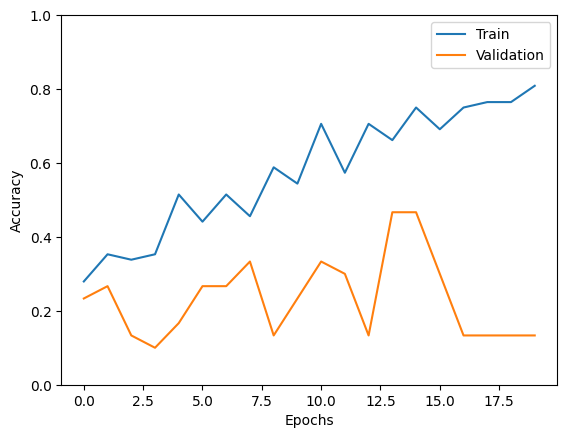

In [ ]:
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.ylim(0,1)
plt.legend()

In [ ]:
# We can see that our model is highly overfitting, and the validation accuracy seems to be random. Lets investigate.

In [ ]:
def predict_and_display(image, true_label, model, encoder, grayscale=True):
    """
    Predicts the class of an image using the trained model, and displays it
    alongside the true and predicted labels.

    Parameters:
        image (np.ndarray): The input image (2D or 3D array).
        true_label (str or np.ndarray): The original class name or one-hot array.
        model (sklearn or keras-style model): The trained model with a .predict() method.
        encoder (OneHotEncoder): Fitted encoder to decode predictions.
        grayscale (bool): Whether the image is grayscale or RGB.
    """

    # Prepare the image shape for the model
    if image.ndim == 2:  # grayscale
        image_input = image[np.newaxis, ..., np.newaxis]  # shape: (1, H, W, 1)
    elif image.ndim == 3:  # RGB
        image_input = image[np.newaxis, ...]  # shape: (1, H, W, C)
    else:
        raise ValueError("Unexpected image shape: {}".format(image.shape))

    # Make prediction
    prediction = model.predict(image_input)
    predicted_class = encoder.inverse_transform(prediction)[0][0]

    # Decode true class (if needed)
    if isinstance(true_label, np.ndarray):
        true_class = encoder.inverse_transform(true_label.reshape(1, -1))[0][0]
    else:
        true_class = true_label

    # Display image with labels
    plt.figure(figsize=(4, 4))
    cmap = 'gray' if grayscale else None
    plt.imshow(image, cmap=cmap)
    plt.axis('off')
    plt.title(f"True: {true_class}\nPredicted: {predicted_class}", fontsize=12)
    plt.show()


2025-07-10 17:02:08.254461: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.6 = (f32[1,32,1022,1022]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,1,1024,1024]{3,2,1,0} %bitcast.333, f32[32,1,3,3]{3,2,1,0} %bitcast.340, f32[32]{0} %bitcast.342), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_26_1/conv2d_46_1/convolution" source_file="/opt/jupyterhub/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-10 17:02:08.440046: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time 

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


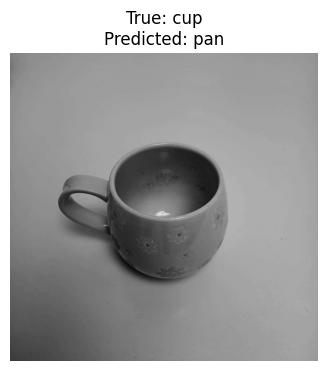

In [ ]:
predict_and_display(x_test[0], y_test[0], model, encoder)

In [ ]:
import random
def predict_n_per_class(X, y, model, encoder, N=3, grayscale=True):
    """
    For each class, predict and display N sample images.

    Parameters:
        X (np.ndarray): Array of images (e.g., shape (num_samples, H, W) or (num_samples, H, W, C))
        y (np.ndarray): Labels (either as strings or one-hot encoded)
        model: Trained model with .predict()
        encoder (OneHotEncoder): The fitted encoder to decode predictions
        N (int): Number of samples per class to display
        grayscale (bool): Whether images are grayscale (for correct plotting)
    """
    # Convert one-hot encoded labels to class names if needed
    if y.ndim == 2:
        labels = encoder.inverse_transform(y)
    else:
        labels = y

    labels = labels.flatten()
    unique_classes = np.unique(labels)

    for class_name in unique_classes:
        # Find all indices for this class
        class_indices = np.where(labels == class_name)[0]
        if len(class_indices) < N:
            print(f"Skipping class '{class_name}' (only {len(class_indices)} samples).")
            continue

        # Randomly select N samples from this class
        selected_indices = random.sample(list(class_indices), N)

        print(f"\n=== Class: {class_name} ===")
        for idx in selected_indices:
            predict_and_display(X[idx], labels[idx], model, encoder, grayscale=grayscale)



=== Class: boiler ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


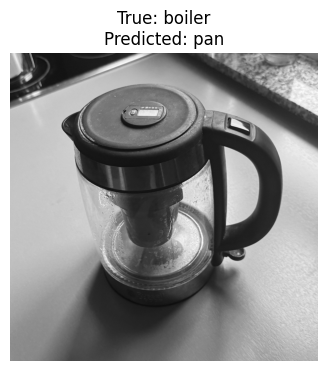

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


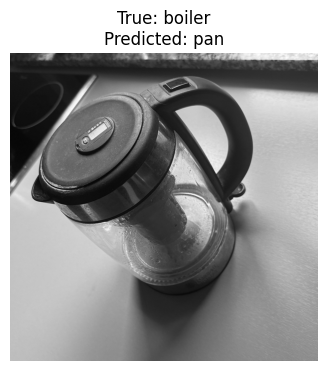

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


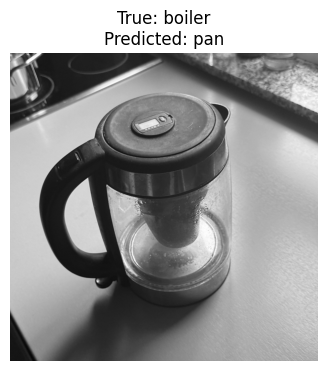


=== Class: cup ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


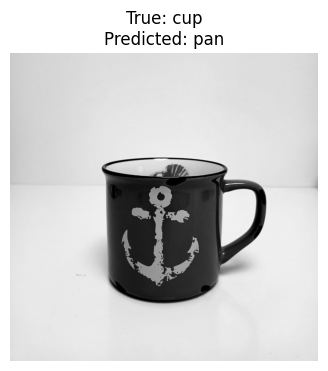

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


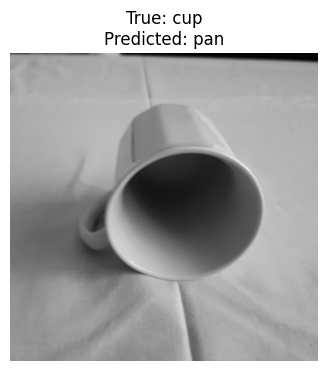

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


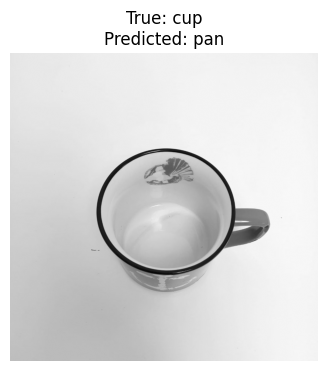


=== Class: knife ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


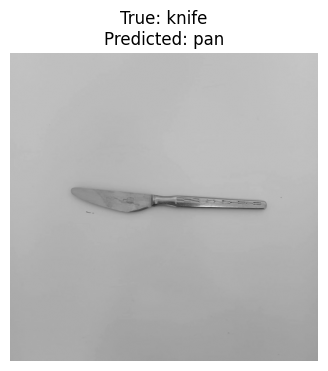

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


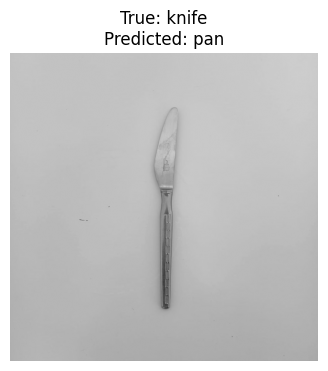

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


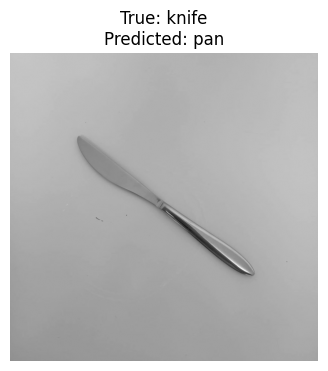


=== Class: pan ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


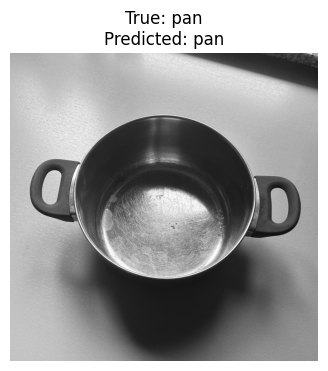

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


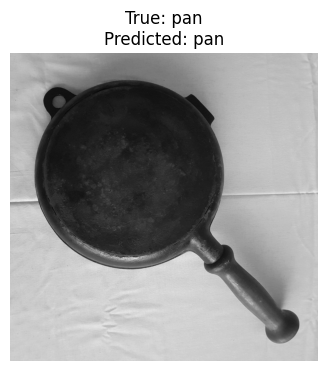

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


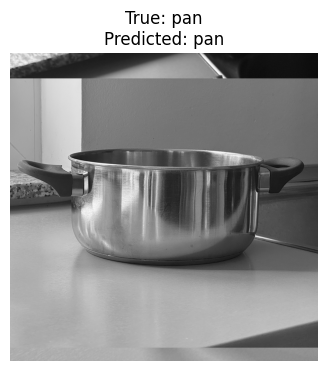


=== Class: spoon ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


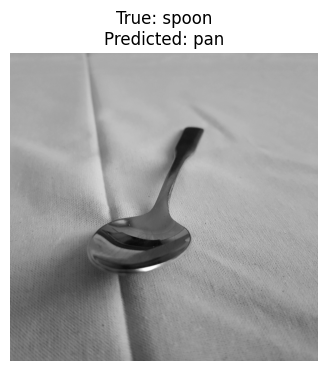

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


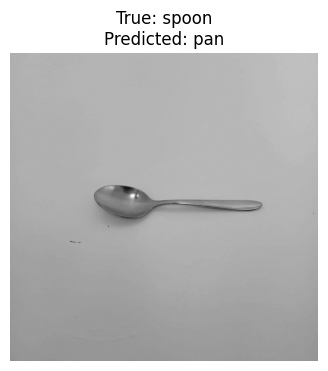

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


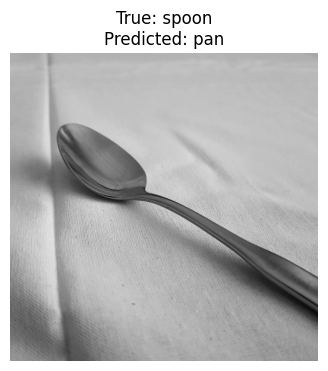

In [ ]:
predict_n_per_class(x_test, y_test, model, encoder, N=3, grayscale=True)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(X, y, model, encoder, grayscale=True, normalize='true'):
    """
    Predicts on the dataset and plots the confusion matrix.

    Parameters:
        X (np.ndarray): Image data (shape: N x H x W or N x H x W x C).
        y (np.ndarray): True labels (string labels or one-hot encoded).
        model: Trained model with .predict() method.
        encoder: OneHotEncoder used during training.
        grayscale (bool): Whether the input images are grayscale.
        normalize (str or None): 'true', 'pred', 'all', or None for raw counts.
    """

    # Prepare X for prediction
    if grayscale and X.ndim == 3:
        X_input = X[..., np.newaxis]  # Add channel dimension
    else:
        X_input = X

    # Predict
    y_pred_probs = model.predict(X_input)
    y_pred = encoder.inverse_transform(y_pred_probs)

    # True labels
    if y.ndim == 2:
        y_true = encoder.inverse_transform(y)
    else:
        y_true = y

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=encoder.categories_[0], normalize=normalize)

    # Plot
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.categories_[0])
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()


2025-07-10 17:02:35.177071: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-10 17:02:35.369333: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-10 17:02:37.335547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-10 17:02:37.523673: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-07-10 17:02:37.795318: W external/local_xla/xla/tsl/fra

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


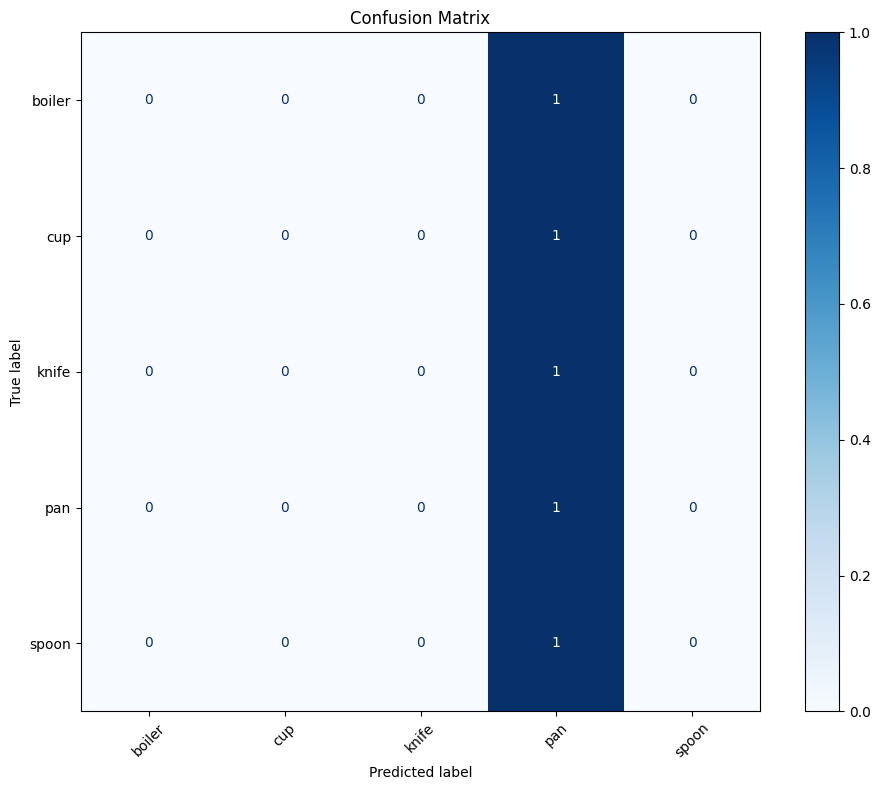

In [ ]:
plot_confusion_matrix(x_test, y_test, model, encoder, grayscale=True)

In [ ]:
# Why does this happen? Lets look at the amount of samples per class again
df_clean.Image_name.value_counts()

Image_name
knife     30
spoon     24
cup       22
pan       13
boiler     9
Name: count, dtype: int64

In [ ]:
# The knife class has the most samples, as our model is not great, the model figures out that the probability of being correct is highest if it just always predicts the knive class. Other options is that it just chooses one class and always predicts that to achieve atleast random.
# Lets try with a balanced amount of data
from sklearn.utils import resample

In [ ]:
def balance_dataframe_by_class(df, label_column='Image_name'):
    class_counts = df['Image_name'].value_counts()
    valid_classes = class_counts[class_counts >= 20].index
    df = df[df['Image_name'].isin(valid_classes)]
    class_counts = df[label_column].value_counts()
    min_count = class_counts.min()

    balanced_df = []
    for label in class_counts.index:
        class_df = df[df[label_column] == label]
        balanced_class_df = resample(class_df, replace=False, n_samples=min_count, random_state=42)
        balanced_df.append(balanced_class_df)

    return pd.concat(balanced_df).sample(frac=1, random_state=14).reset_index(drop=True)

In [ ]:
df_balanced = balance_dataframe_by_class(df_clean)

In [ ]:
df_balanced.Image_name.value_counts()

Image_name
cup      22
knife    22
spoon    22
Name: count, dtype: int64

In [ ]:
x_train, x_test, y_train, y_test, encoder = createTrainTestSplit(df_balanced)

(46, 1024, 1024) (20, 1024, 1024) (46, 3) (20, 3)


In [ ]:
model = Sequential()  

# Convolution Layer 1
model.add(Conv2D(12, (3, 3), input_shape=(x_train[0].shape[0],x_train[0].shape[1],1), padding='same'))  
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Optional second Conv Block
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(layers.GlobalAveragePooling2D())
model.add(Dense(32, activation='relu'))                                                                   
model.add(Dropout(0.25))   
# Output Layer
                           
model.add(Dense(y_test[0].shape[0], activation='softmax'))                                
                   
model.summary()

/opt/jupyterhub/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 1024, 1024, 12) │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 1024, 1024, 12) │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_58 (Activation)      │ (None, 1024, 1024, 12) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 512, 512, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 512, 512, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 512, 512, 32)   │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 512, 512, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_59 (Activation)      │ (None, 512, 512, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,939 (19.29 KB)

 Trainable params: 4,851 (18.95 KB)

 Non-trainable params: 88 (352.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
np.sum(y_train, axis=0), np.sum(y_test, axis=0)

(array([15., 15., 16.]), array([7., 7., 6.]))

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=1e-3), metrics=['accuracy'])

callbacks = [
    # EarlyStopping(patience=20, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5)
]

history = model.fit(x_train, y_train,
                    batch_size=6,
                    validation_data = (x_test, y_test),
                    epochs=200,
                   callbacks=callbacks)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 661ms/step - accuracy: 0.5229 - loss: 0.8997 - val_accuracy: 0.5000 - val_loss: 1.0394 - learning_rate: 0.0010
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5703 - loss: 0.8884 - val_accuracy: 0.5000 - val_loss: 1.0345 - learning_rate: 0.0010
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5764 - loss: 0.8911 - val_accuracy: 0.5000 - val_loss: 1.0279 - learning_rate: 0.0010
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3716 - loss: 1.0283 - val_accuracy: 0.4500 - val_loss: 1.0513 - learning_rate: 0.0010
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5658 - loss: 0.8630 - val_accuracy: 0.4000 - val_loss: 1.0564 - learning_rate: 0.0010
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5366 - loss: 0.9014 - val_accuracy: 0.5500 - val_loss: 1.0301 - learning_rate: 0.0010
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4560 - loss: 0.9241 - val_accuracy

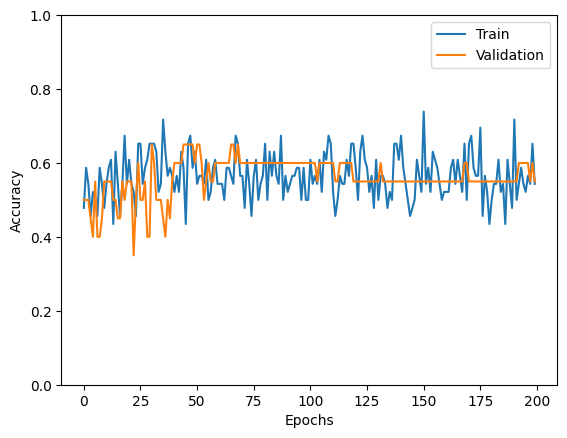

In [ ]:
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.ylim(0,1)
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


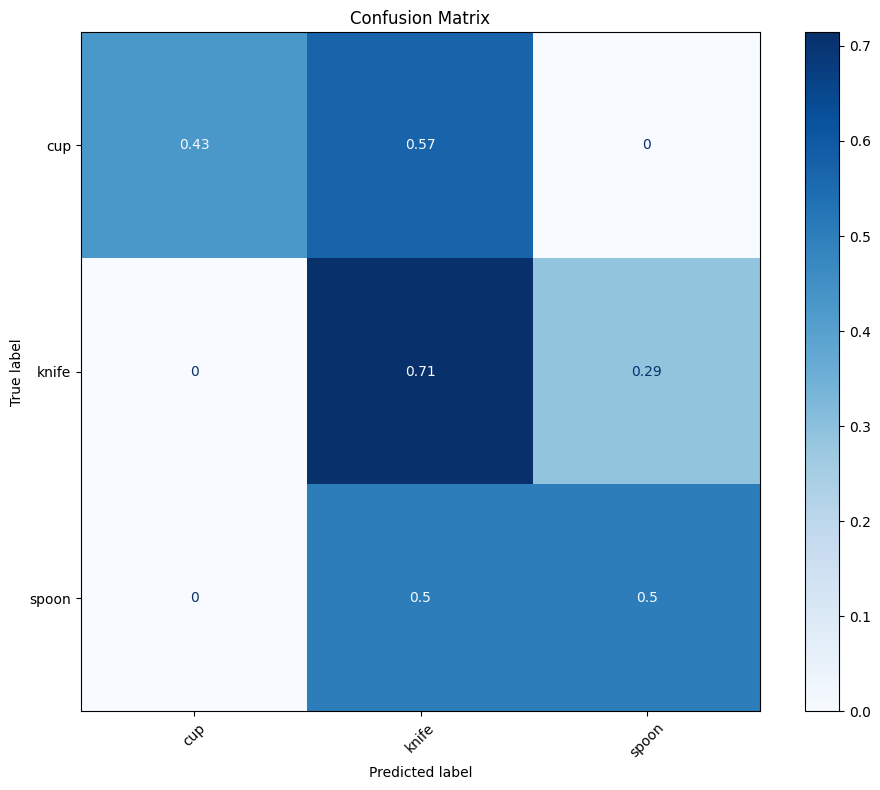

In [ ]:
plot_confusion_matrix(x_test, y_test, model, encoder, grayscale=True)

# Data Augmentation
Becoming better, but still not great. Lets try to use our augmented data to increase the amount of different samples per class

In [ ]:
df_aug = df.copy()
df_aug.Image_name = df_aug.Image_name.apply(lambda x: x.lower())
df_aug.Image_name = df_aug.Image_name.map(name_mapper_dict)
class_counts = df_aug['Image_name'].value_counts()
valid_classes = class_counts[class_counts >= 60].index
df_aug = df_aug[df_aug['Image_name'].isin(valid_classes)]
df_aug = balance_dataframe_by_class(df_aug)
df_aug.Image_name.value_counts()

Image_name
knife    88
cup      88
spoon    88
Name: count, dtype: int64

In [ ]:
x_train, x_test, y_train, y_test, encoder = createTrainTestSplit(df_aug)

(184, 1024, 1024) (80, 1024, 1024) (184, 3) (80, 3)


In [ ]:
model = Sequential()  

# Convolution Layer 1
model.add(Conv2D(24, (3, 3), input_shape=(x_train[0].shape[0],x_train[0].shape[1],1), padding='same'))  
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Optional second Conv Block
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(layers.GlobalAveragePooling2D())
model.add(Dense(32, activation='relu'))                                                                   
model.add(Dropout(0.25))   
# Output Layer
                           
model.add(Dense(y_test[0].shape[0], activation='softmax'))                                
                   
model.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 1024, 1024, 24) │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 1024, 1024, 24) │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_62 (Activation)      │ (None, 1024, 1024, 24) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 512, 512, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 512, 512, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 512, 512, 32)   │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 512, 512, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_63 (Activation)      │ (None, 512, 512, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,563 (33.45 KB)

 Trainable params: 8,451 (33.01 KB)

 Non-trainable params: 112 (448.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=['accuracy'])

callbacks = [
    # EarlyStopping(patience=20, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5)
]

history = model.fit(x_train, y_train,
                    batch_size=12,
                    validation_data = (x_test, y_test),
                    epochs=100,
                   callbacks=callbacks)

Epoch 1/100


2025-07-10 17:37:27.000878: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.6 = (f32[12,24,1024,1024]{3,2,1,0}, u8[0]{0}) custom-call(f32[12,1,1024,1024]{3,2,1,0} %bitcast.10384, f32[24,1,3,3]{3,2,1,0} %bitcast.10075, f32[24]{0} %bitcast.10845), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_29_1/conv2d_52_1/convolution" source_file="/opt/jupyterhub/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-10 17:37:27.237820: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed

15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3154 - loss: 1.7353

2025-07-10 17:37:33.762415: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.6 = (f32[4,24,1024,1024]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,1,1024,1024]{3,2,1,0} %bitcast.10378, f32[24,1,3,3]{3,2,1,0} %bitcast.10077, f32[24]{0} %bitcast.10832), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_29_1/conv2d_52_1/convolution" source_file="/opt/jupyterhub/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-10 17:37:33.943479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed o

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.3160 - loss: 1.7319

2025-07-10 17:37:38.820079: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.6 = (f32[8,24,1024,1024]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,1,1024,1024]{3,2,1,0} %bitcast.534, f32[24,1,3,3]{3,2,1,0} %bitcast.541, f32[24]{0} %bitcast.543), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_29_1/conv2d_52_1/convolution" source_file="/opt/jupyterhub/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-10 17:37:39.036418: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: me

16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 525ms/step - accuracy: 0.3166 - loss: 1.7290 - val_accuracy: 0.3250 - val_loss: 2.6867 - learning_rate: 1.0000e-04
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.2877 - loss: 1.4384 - val_accuracy: 0.3250 - val_loss: 1.3539 - learning_rate: 1.0000e-04
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.3372 - loss: 1.3493 - val_accuracy: 0.3375 - val_loss: 1.3088 - learning_rate: 1.0000e-04
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.3621 - loss: 1.2526 - val_accuracy: 0.3375 - val_loss: 1.3639 - learning_rate: 1.0000e-04
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.4108 - loss: 1.1485 - val_accuracy: 0.3375 - val_loss: 1.3917 - learning_rate: 1.0000e-04
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.3848 - loss: 1.2502 - val_accuracy: 0.3375 - val_loss: 1.3184 - learning_rate: 1.0000e-04
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.3656 - l

# Final classification thoughts
As we do not have that much data, our models will never be able to achieve amazing results. However, with more hyperparameter tuning we see that its possible to achieve ~70% validation accuracy. 
We want a stable model. This means the model should slowly converge towards its optimum with accuracy ~= validation_accuracy. If the accuracy is way higher than the validation accuracy, our model is overfitting (learned the training data "by heart").
If accuracy way lower than validation accuracy, our model did not yet learn all potential feature to distinguish all classes. This usually means we want to add more learnable parameters (more kernels, layers, ...)

# Bounding Box Prediction

Now that we have a somewhat stable classification, we can look at building a second model which is able to predict the bounding box of each object. For this we do not have to split between different classes, as to predict the bounding box its irrelevant which object is shown. For this we can also take the data of classes with low samples.

In [ ]:
def preprocess_for_boundingbox(df, grayscale=True):
    """
    Prepares image and bounding box data for training a bounding box regressor.

    Parameters:
        df (pd.DataFrame): DataFrame with image data and bounding box labels.
        grayscale (bool): Whether to convert images to grayscale.

    Returns:
        X (np.ndarray): Preprocessed images.
        y (np.ndarray): Bounding box targets (X_pos, Y_pos, Width, Height).
    """
    import cv2
    import numpy as np

    images = df['Image_data'].values
    boxes = df[['X_pos', 'Y_pos', 'Width', 'Height']].values.astype('float32')

    # Convert to grayscale and stack
    if grayscale:
        images = np.stack([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in images])
        images = images[..., np.newaxis]  # Add channel dimension: (N, H, W, 1)
    else:
        images = np.stack(images)

    return images, boxes

In [ ]:
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
def build_boundingbox_model(input_shape):
    """
    Builds a simple CNN for bounding box regression.

    Parameters:
        input_shape (tuple): Shape of the input image (H, W, C)

    Returns:
        model: Compiled Keras model
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(48, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(3,3)),  
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(3,3)),  
        layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(3,3)),  
        layers.Flatten(),
        layers.Dense(30, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(15, activation='relu'),
        layers.Dense(4)  # Output: X_pos, Y_pos, Width, Height
    ])

    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model


In [ ]:
# Step 1: Preprocess
X, y = preprocess_for_boundingbox(df)

In [ ]:
X.shape, y.shape

((98, 1024, 1024, 1), (98, 4))

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(129, 1024, 1024, 1)

In [ ]:
model = build_boundingbox_model(input_shape=X_train.shape[1:])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 1024, 1024, 48) │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 341, 341, 48)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 341, 341, 32)   │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 113, 113, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 113, 113, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 37, 37, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 21904)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 30)             │       657,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │            64 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 676,639 (2.58 MB)

 Trainable params: 676,639 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=70, batch_size=8)

Epoch 1/70


2025-07-10 16:05:26.685011: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.9 = (f32[8,48,1024,1024]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,1,1024,1024]{3,2,1,0} %bitcast.4863, f32[48,1,3,3]{3,2,1,0} %bitcast.4708, f32[48]{0} %bitcast.5213), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_8_1/conv2d_14_1/convolution" source_file="/opt/jupyterhub/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-10 16:05:26.905309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: 

15/17 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 144633.8281 - mae: 304.0852

2025-07-10 16:05:31.084019: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.9 = (f32[1,48,1024,1024]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,1,1024,1024]{3,2,1,0} %bitcast.4895, f32[48,1,3,3]{3,2,1,0} %bitcast.4725, f32[48]{0} %bitcast.5253), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_8_1/conv2d_14_1/convolution" source_file="/opt/jupyterhub/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-10 16:05:31.254704: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: 

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - loss: 142194.2812 - mae: 300.8279

2025-07-10 16:05:33.793006: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.9 = (f32[8,48,1024,1024]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,1,1024,1024]{3,2,1,0} %bitcast.329, f32[48,1,3,3]{3,2,1,0} %bitcast.336, f32[48]{0} %bitcast.338), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_8_1/conv2d_14_1/convolution" source_file="/opt/jupyterhub/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-07-10 16:05:34.011177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: mea

17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 362ms/step - loss: 141156.2969 - mae: 299.4412 - val_loss: 69208.6797 - val_mae: 193.3982
Epoch 2/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 83497.0781 - mae: 229.3029 - val_loss: 60655.4062 - val_mae: 183.2464
Epoch 3/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 63341.5078 - mae: 198.1126 - val_loss: 57592.6680 - val_mae: 180.8171
Epoch 4/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 56717.1328 - mae: 185.5352 - val_loss: 40596.8711 - val_mae: 154.9040
Epoch 5/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 58874.3203 - mae: 190.1550 - val_loss: 44008.7148 - val_mae: 164.1269
Epoch 6/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 52808.8789 - mae: 180.6158 - val_loss: 50542.8633 - val_mae: 169.7669
Epoch 7/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 47351.1992 - mae: 168.7310 - val_loss: 45384.2305 - val_mae: 160.9122
Epoch 8/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 42605.0977 - mae: 164.6403 - val_loss: 40425.2

In [ ]:
def evaluate_boundingbox_predictions(X, y_true, model, N=5, grayscale=True):
    """
    Randomly selects N samples, predicts bounding boxes, and plots results.

    Parameters:
        X (np.ndarray): Image data (N, H, W, C or N, H, W).
        y_true (np.ndarray): Ground truth bounding boxes (N, 4).
        model: Trained bounding box prediction model.
        N (int): Number of samples to show.
        grayscale (bool): Whether to treat input as grayscale images.
    """
    import random

    indices = random.sample(range(len(X)), N)
    for idx in indices:
        image = X[idx]
        true_box = y_true[idx]
        
        # Add batch and channel dims if needed
        img_input = image[np.newaxis, ...]
        if grayscale and image.ndim == 2:
            img_input = img_input[..., np.newaxis]
        
        pred_box = model.predict(img_input)[0]
        plot_boundingbox_prediction(image.squeeze(), true_box, pred_box, grayscale=grayscale)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


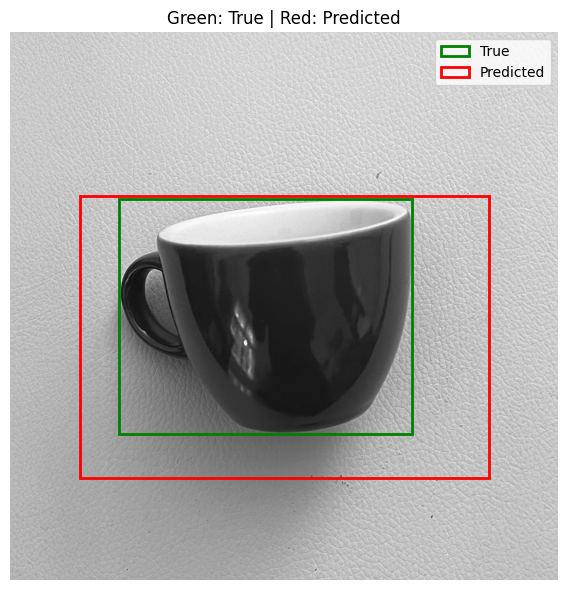

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


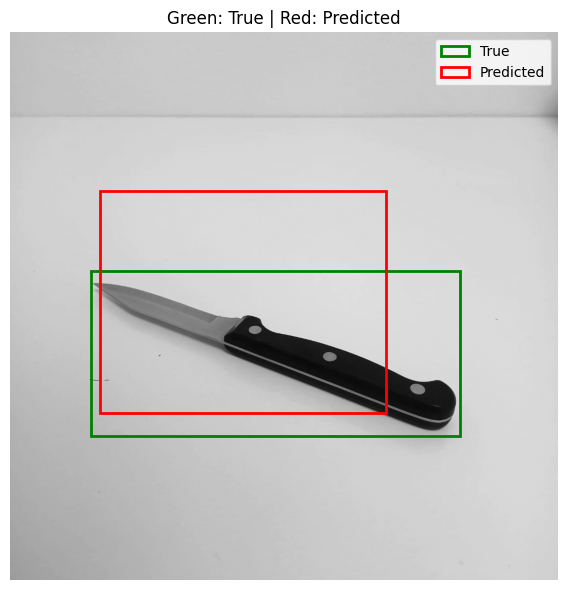

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


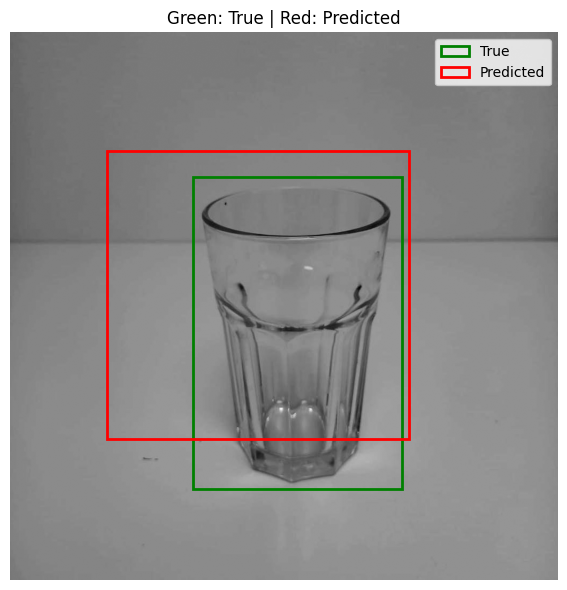

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


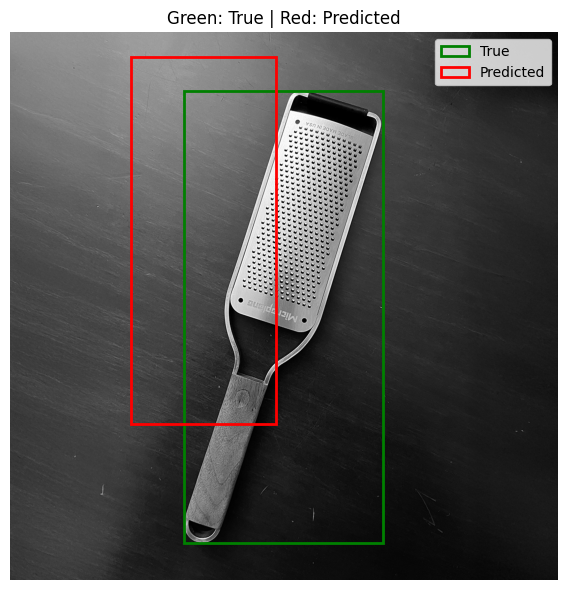

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


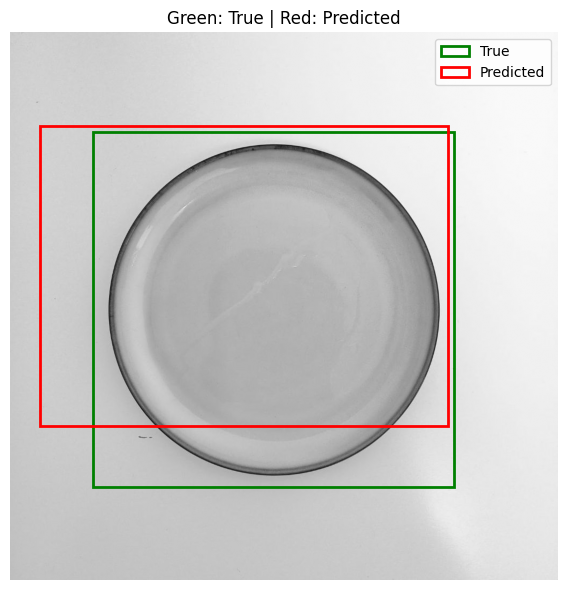

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


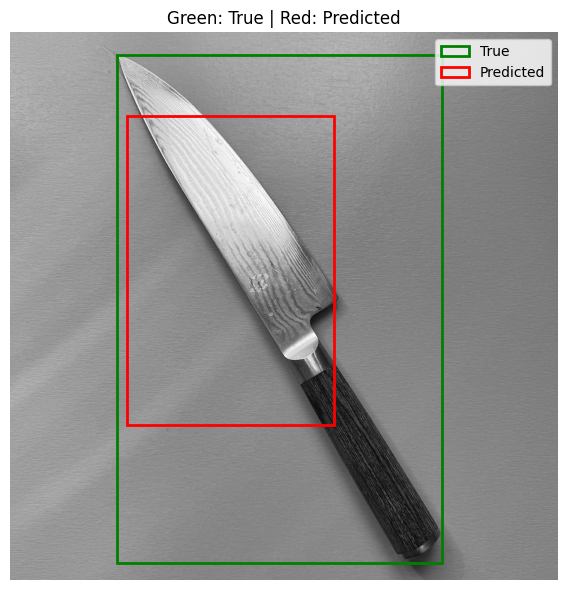

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


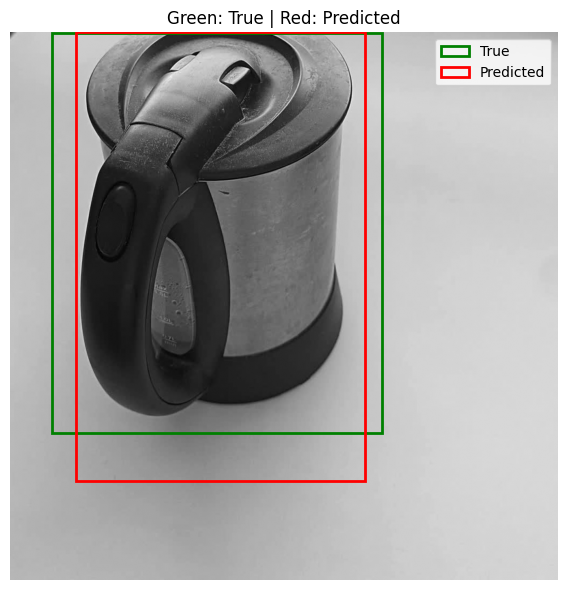

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


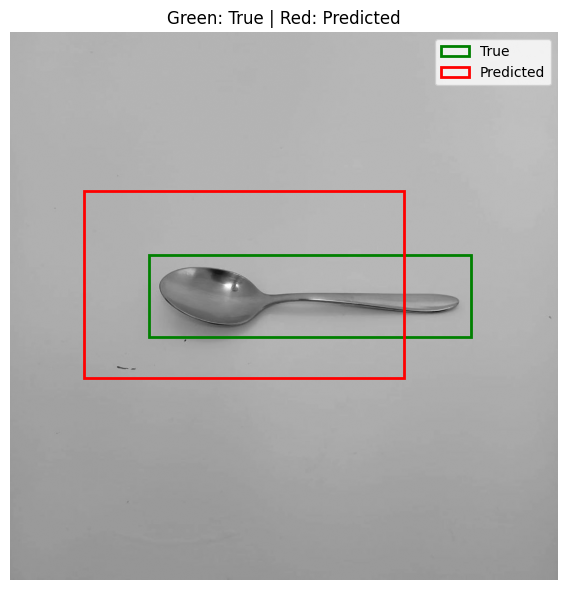

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


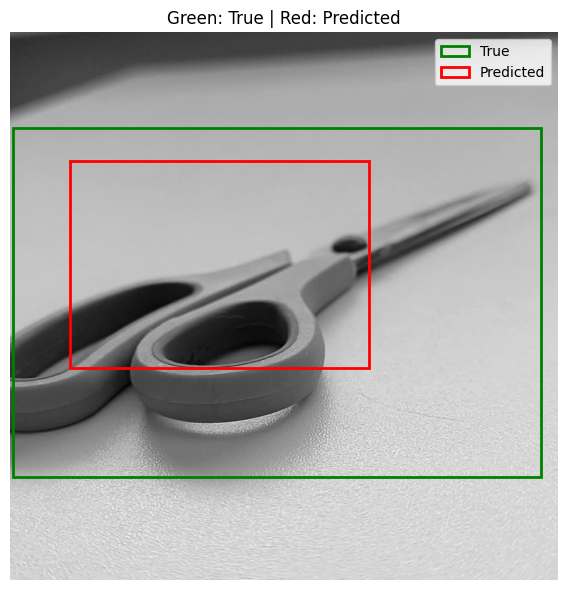

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


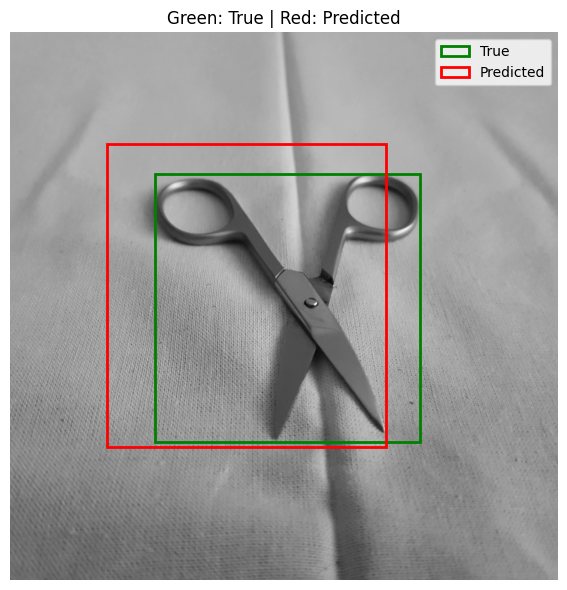

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


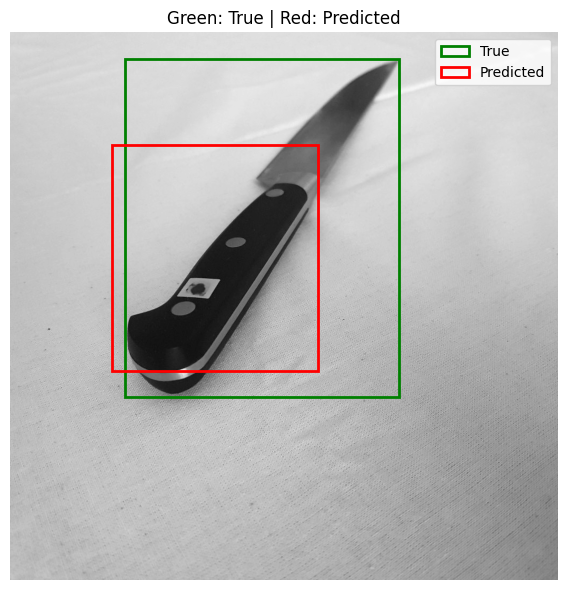

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


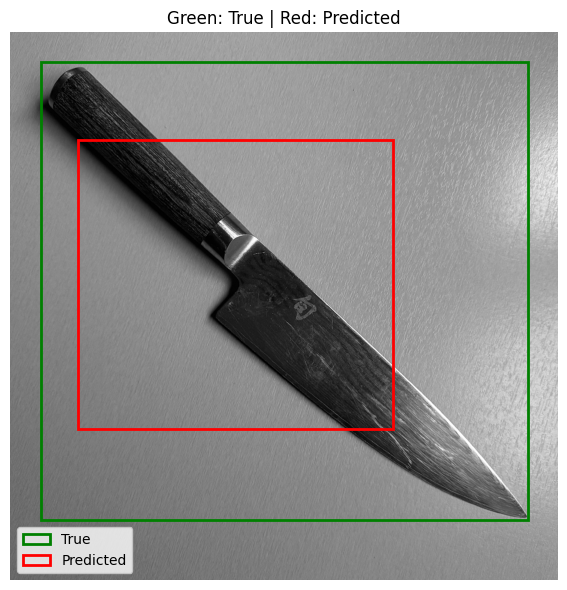

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


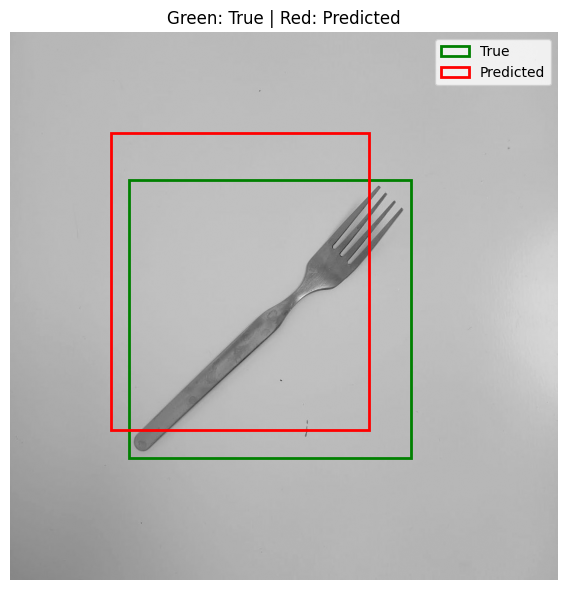

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


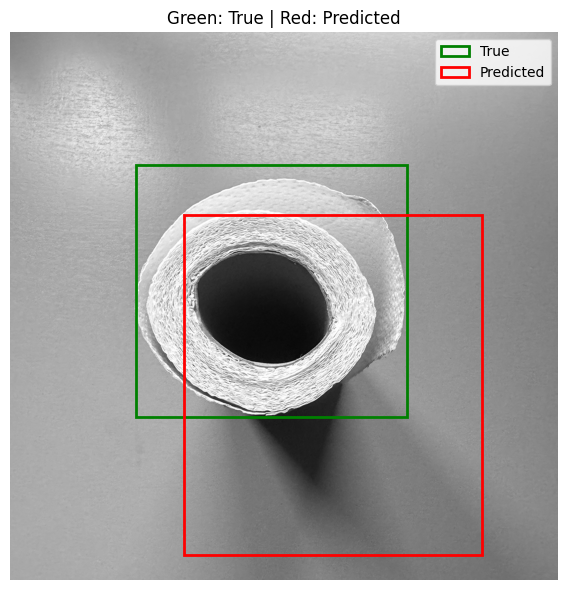

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


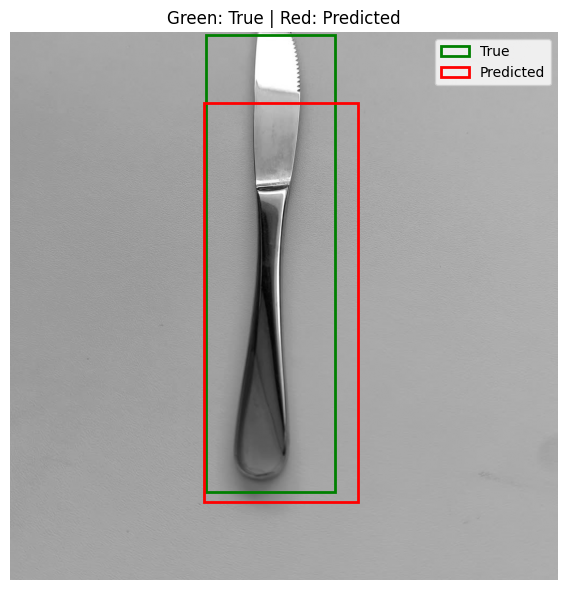

In [ ]:
evaluate_boundingbox_predictions(X_val, y_val, model, N=15, grayscale=True)


# How to improve?
1. More data
2. Normalizing the data (to values between 0 and 1)
3. Hyperparametertuning

# Future Steps
If we had a good bounding box model, we could use that to first detect an object in an image, crop the image to only be the content of the bounding box, insert that into an empty image with a defined size, and then train our classification network on the output of that. This would also allow to detect multiple objects per image